In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Task 1: Exploratory Data Analysis (EDA)

In [2]:
df=pd.read_csv("Pharma_Industry (1).csv")

In [3]:
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [5]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [7]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [8]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [9]:
df.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

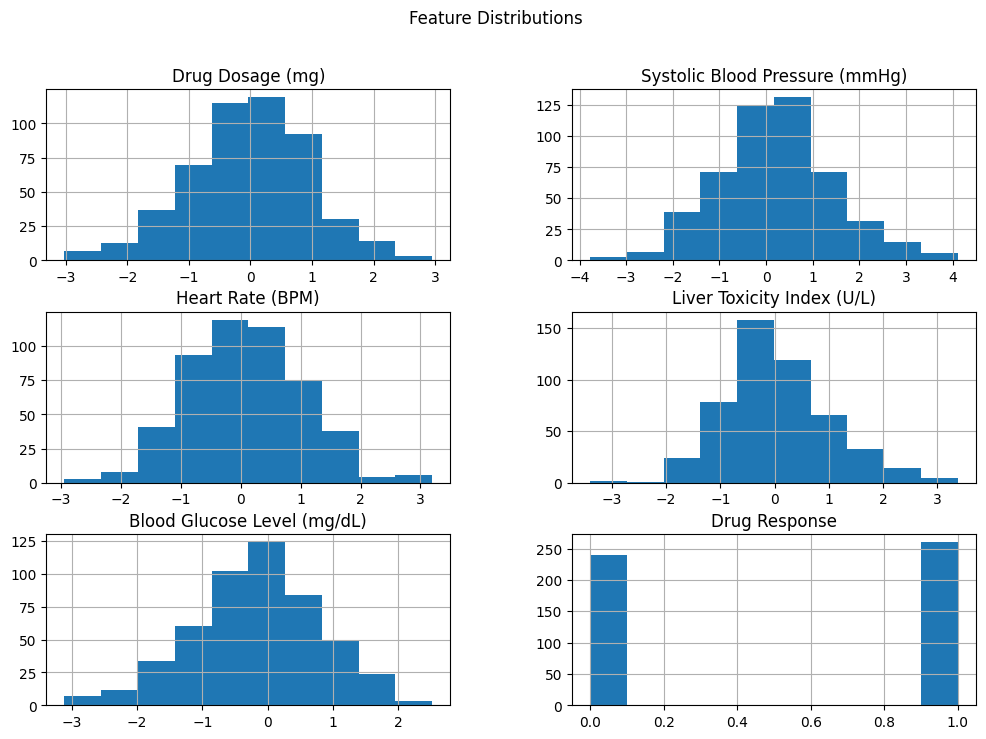

In [10]:
### Histogram
df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

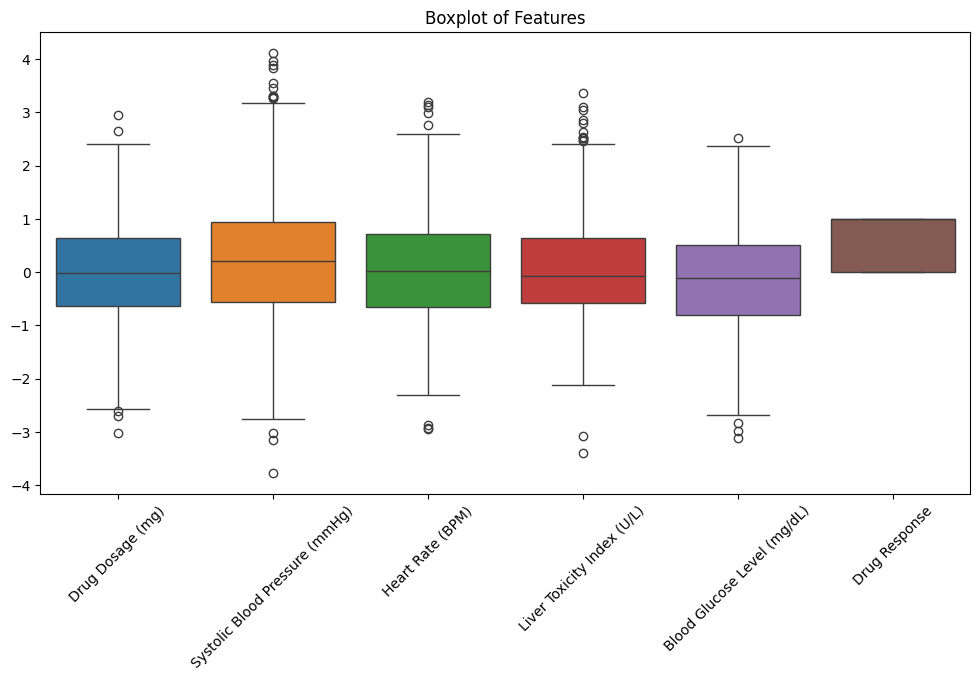

In [11]:
### Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

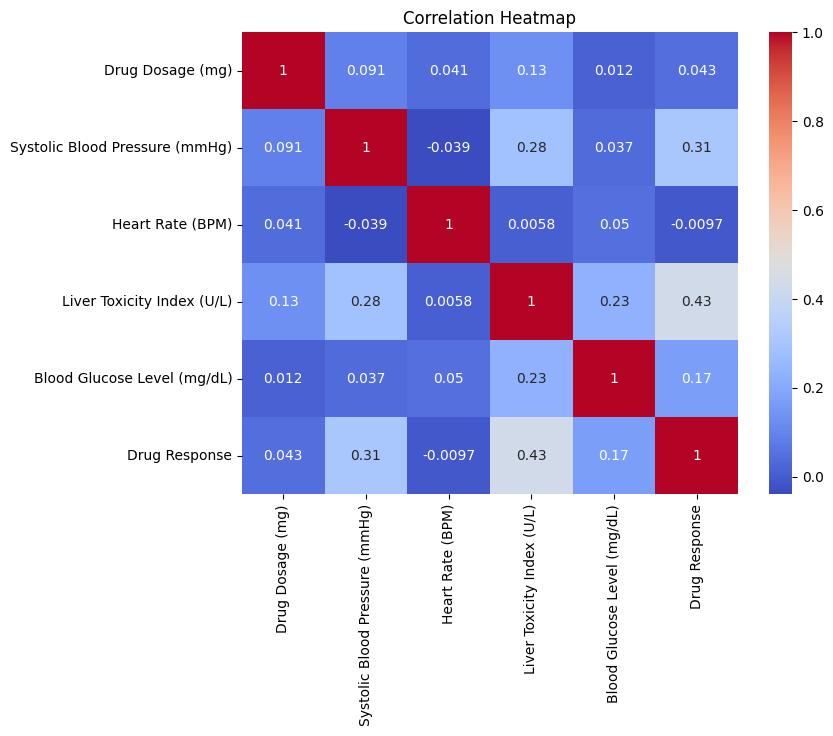

In [13]:
### Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Task 2: Data Preprocessing



In [14]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
# Features and target
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Task 3: Data Visualization

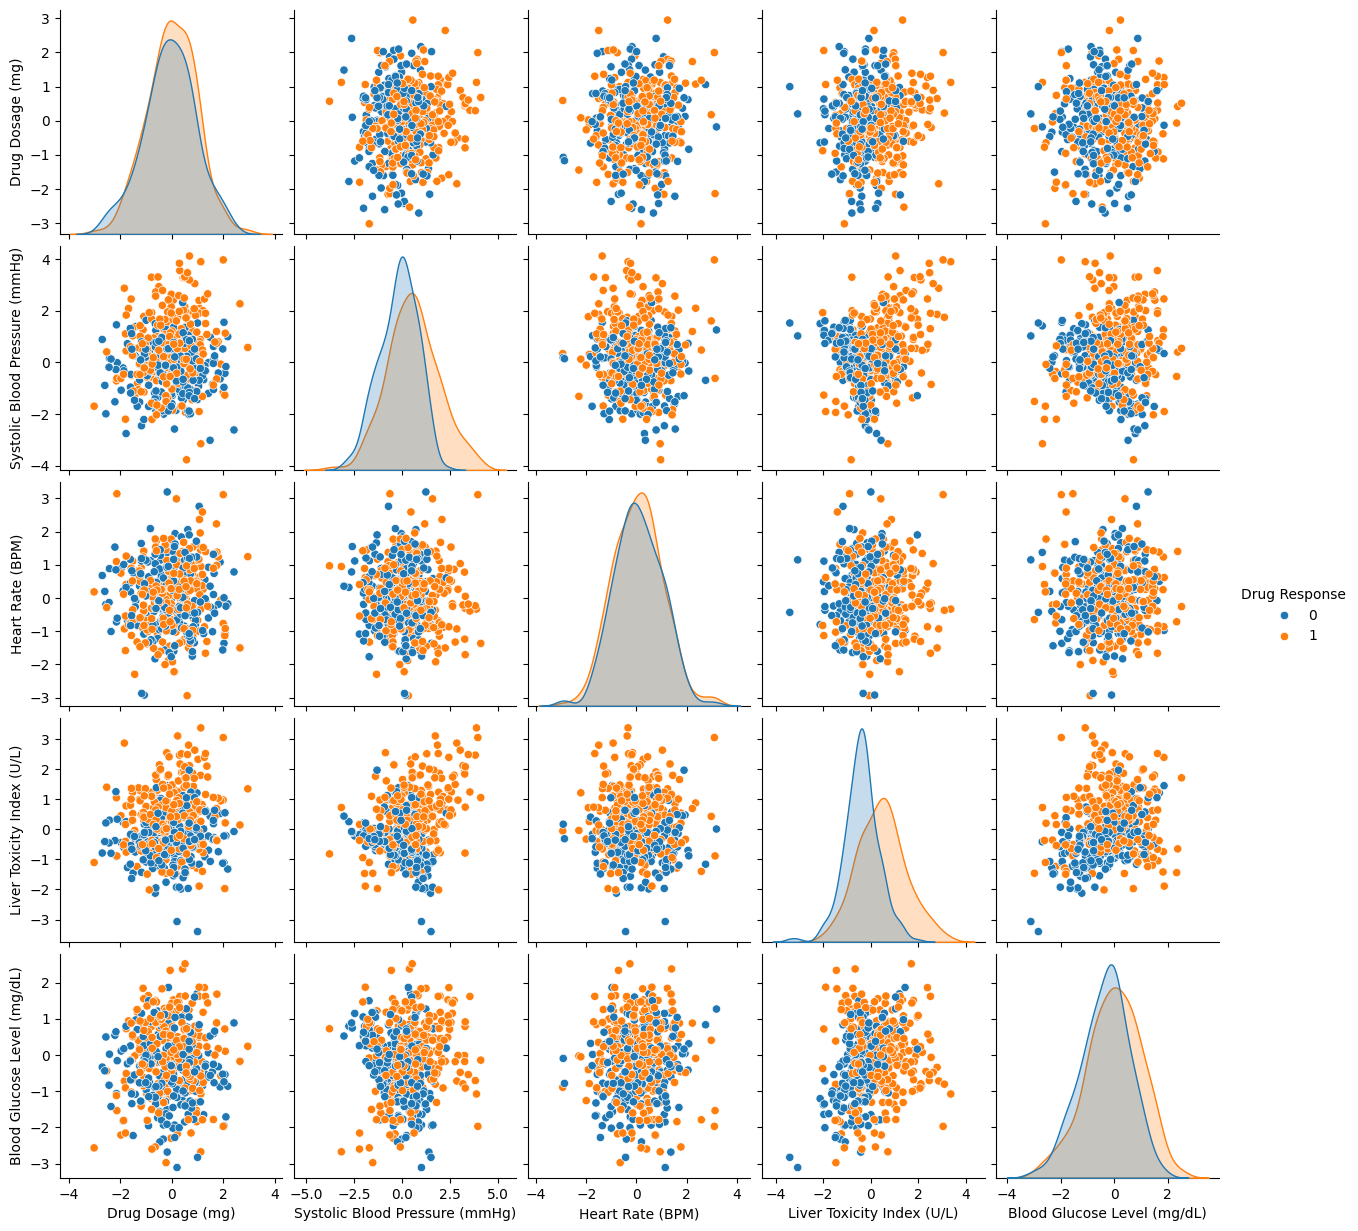

In [23]:
### Pair Plot
sns.pairplot(df, hue="Drug Response")
plt.show()

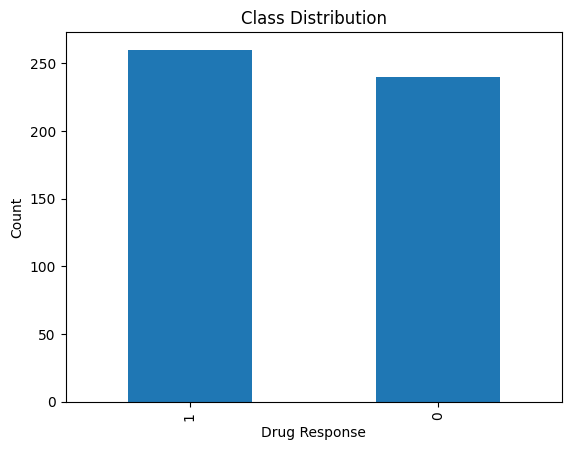

In [25]:
### Class Distribution
plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Drug Response")
plt.ylabel("Count")
plt.show()

### Task 4: SVM Implementation

In [27]:
from sklearn.svm import SVC

In [28]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

In [29]:
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
# Predictions
y_pred = svm_model.predict(X_test_scaled)

In [35]:
#Accuracy
accuracy=svm_model.score(X_test_scaled,y_test)
accuracy

0.77

### TASK 5: Visualization of SVM Results

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# make prediction on the test size
y_pred=svm_model.predict(X_test)

# Generate the confusion matrix
cm=confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues',cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [38]:
# Recall
from sklearn.metrics import recall_score
recall =recall_score(y_test, y_pred)
print(f"Recall score: {recall:.4f}")

Recall score: 0.8077


In [39]:
# Precision Score
from sklearn.metrics import precision_score
precision=precision_score(y_test,y_pred)
print(f"Precision Score: {precision:.4f}")

Precision Score: 0.7500


In [40]:
# f1 score
from sklearn.metrics import f1_score
f1=f1_score(y_test,y_pred)
print(f"F1_score: {f1:.4f}")

F1_score: 0.7778


### TASK 6: Parameter Tuning & Optimization

In [43]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [44]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['linear', 'poly', 'rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best Accuracy: 0.7575000000000001


### TASK 7: Comparison of Kernels

In [56]:
kernels = ['linear', 'poly', 'rbf']
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    print(f"\nKernel: {k}")
    print("Accuracy:", svm_model.score(X_test,y_test))


Kernel: linear
Accuracy: 0.76

Kernel: poly
Accuracy: 0.76

Kernel: rbf
Accuracy: 0.76


C:\Users\Yashwant\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
C:\Users\Yashwant\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
C:\Users\Yashwant\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


#### 2. Analysis of SVM Strengths and Weaknesses Based on EDA & Visualization
### Strengths
##### Handles Numerical & Continuous Features Well. EDA showed all features (drug dosage, blood pressure, heart rate, glucose, liver toxicity) are continuous numerical variables.
##### Effective with Non-Linear Relationships. Correlation heatmap and scatter plots indicated non-linear relationships between physiological parameters and drug response.

##### The RBF kernel outperformed linear and polynomial kernels, confirming that SVM successfully captured non-linear decision boundaries.

### Weaknesses

#### Sensitive to Feature Scaling
#### EDA revealed large variation in feature ranges.
#### Without scaling, SVM performance drops significantly, making preprocessing mandatory.

### Practical Implications of SVM in Real-World Classification Tasks

##### Medical Diagnosis & Drug Response Prediction

##### SVM can classify patient responses to drugs based on physiological indicators.

##### Helps in personalized medicine by predicting whether a patient will respond positively or negatively to treatment.

##### Clinical Decision Support Systems

##### SVM models can assist doctors by providing predictive insights from historical patient data.

##### Useful as a support tool, not a replacement for clinical judgment.

##### High-Dimensional Data Applications

##### SVM performs well even when the number of features increases.

##### Commonly used in bioinformatics, genomics, and pharmaceutical research.

##### Fraud Detection & Risk Classification

##### Beyond healthcare, SVM is widely applied in finance for credit risk analysis and fraud detection due to its strong classification boundaries.

##### Text and Image Classification

##### SVM is frequently used in spam detection, sentiment analysis, and medical image classification when data size is moderate.